# CLUSTERING AND ANALYSIS OF PROSEG SEGMENTED DATA

<span style="font-size: 1.3em;">
ProSeg performs ab initio cell segmentation using an unsupervised, probabilistic model of the spatial distribution of transcripts.  
Instead of relying only on nuclei or membrane staining, ProSeg uses a cellular Potts–inspired model that simulates rudimentary cellular behaviors on a lattice of pixels. The algorithm fits a probabilistic spatial model to the observed transcript locations and image-based probability maps to infer cell boundaries.
</span>

## DEFINE FUNCTIONS

In [1]:
import warnings
warnings.filterwarnings("ignore")
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib import colors as mcolors
import warnings
warnings.filterwarnings("ignore")

from pandas.api.types import is_numeric_dtype, is_categorical_dtype


def plot_spatial_compact_fast(
    ad,
    color="leiden_2",
    groupby="sample_id",
    spot_size=8,
    cols=3,
    height=8,
    legend_col_width=1.2,
    palette=None,
    rasterized=True,
    invert_y=True,
    dpi=120,
    highlight=None,
    group_order=None,
    background="white",
    grey_alpha=0.2,         # <-- NEW: alpha for non-highlighted clusters
):
    # pick background + text color
    fig_face = background
    ax_face = background
    text_color = "white" if background in ("black", "#000000", "k") else "black"

    # ----- 0) Preconditions -----
    if "spatial" not in ad.obsm:
        raise ValueError("ad.obsm['spatial'] not found")

    if color not in ad.obs.columns:
        raise KeyError(f"Column {color!r} not found in ad.obs")

    if groupby not in ad.obs.columns:
        raise KeyError(f"groupby {groupby!r} not in ad.obs")

    col_series = ad.obs[color]

    # Detect continuous vs categorical robustly
    if is_categorical_dtype(col_series):
        is_continuous = False
    else:
        is_continuous = is_numeric_dtype(col_series)

    coords = np.asarray(ad.obsm["spatial"])[:, :2]
    col_series = ad.obs[color]

    # ----------------------------------------------------
    # 1) Build colors_arr differently for cont vs cat
    # ----------------------------------------------------
    if is_continuous:
        # ===== CONTINUOUS MODE =====
        vals = col_series.to_numpy(dtype=float)

        # choose colormap
        if palette is None:
            cmap = plt.get_cmap("viridis")
        elif isinstance(palette, str):
            cmap = plt.get_cmap(palette)
        else:
            cmap = palette

        # robust min/max
        finite_mask = np.isfinite(vals)
        if finite_mask.sum() == 0:
            raise ValueError(f"All values for '{color}' are NaN or non-finite.")
        vmin = np.min(vals[finite_mask])
        vmax = np.max(vals[finite_mask])
        if vmin == vmax:
            vmin -= 1.0
            vmax += 1.0

        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

        colors_arr = np.zeros((vals.size, 4), dtype=float)
        colors_arr[finite_mask] = cmap(norm(vals[finite_mask]))
        colors_arr[~finite_mask] = (0, 0, 0, 0)

        ad.uns[f"{color}_continuous"] = {
            "vmin": float(vmin),
            "vmax": float(vmax),
            "cmap": cmap.name if hasattr(cmap, "name") else str(cmap),
        }

        cat_names = None
        cat_codes = None

    else:
        # ===== CATEGORICAL =====
        cats = col_series.astype("category")
        cat_names = cats.cat.categories
        cat_codes = cats.cat.codes.to_numpy()

        if isinstance(palette, dict):
            col_list = [palette[c] for c in cat_names]
        elif isinstance(palette, (list, tuple)):
            if len(palette) < len(cat_names):
                raise ValueError("Palette shorter than number of categories.")
            col_list = list(palette)[:len(cat_names)]
        elif f"{color}_colors" in ad.uns:
            col_list = list(ad.uns[f"{color}_colors"])
            if len(col_list) != len(cat_names):
                raise ValueError(f"{color}_colors length != categories.")
        else:
            base = list(
                sc.pl.palettes.default_64
                if hasattr(sc.pl.palettes, "default_64")
                else sc.pl.palettes.default_102
            )
            reps = int(np.ceil(len(cat_names) / len(base)))
            col_list = (base * reps)[:len(cat_names)]

        ad.uns[f"{color}_colors"] = col_list

        rgba = np.array([mcolors.to_rgba(c) for c in col_list], dtype=float)

        colors_arr = np.empty((cat_codes.size, 4), dtype=float)
        colors_arr[cat_codes >= 0] = rgba[cat_codes[cat_codes >= 0]]
        colors_arr[cat_codes < 0] = (0, 0, 0, 0)

        # ----- highlighting logic -----
        if highlight is not None:
            # allow single value or list/tuple/array
            if not isinstance(highlight, (list, tuple, set, np.ndarray)):
                highlight = [highlight]
            # convert to string for robust matching
            highlight_str = {str(h) for h in highlight}

            cat_name_str = np.array([str(c) for c in cat_names])
            keep_cat_mask = np.isin(cat_name_str, list(highlight_str))  # per-category

            # use user-defined alpha for greyed-out categories
            grey_rgba = (0.8, 0.8, 0.8, float(grey_alpha))

            valid = cat_codes >= 0
            keep_flag = np.zeros_like(cat_codes, dtype=bool)
            keep_flag[valid] = keep_cat_mask[cat_codes[valid]]

            # grey out all non-highlighted cells
            colors_arr[valid & ~keep_flag] = grey_rgba

            # also grey in legend
            col_list = [
                col_list[k] if keep_cat_mask[k] else mcolors.to_hex(grey_rgba)
                for k in range(len(cat_names))
            ]

    # ----------------------------------------------------
    # 2) Precompute group indices
    # ----------------------------------------------------
    gvals = ad.obs[groupby].astype(str).to_numpy()

    if group_order is not None:
        group_order = [str(g) for g in group_order]
        present = set(gvals)
        uniq_groups = [g for g in group_order if g in present]
    else:
        uniq_groups = np.unique(gvals)

    gid_to_idx = {g: i for i, g in enumerate(uniq_groups)}
    gcodes = np.array([gid_to_idx.get(g, -1) for g in gvals], dtype=int)

    group_indices = [np.flatnonzero(gcodes == gi) for gi in range(len(uniq_groups))]

    # ----------------------------------------------------
    # 3) Figure layout
    # ----------------------------------------------------
    n = len(uniq_groups)
    rows = int(np.ceil(n / cols))
    panel_w = height * cols * 0.6 / rows
    fig_w = panel_w + legend_col_width

    plt.ioff()
    fig = plt.figure(figsize=(fig_w, height), dpi=dpi, constrained_layout=False)

    # background for figure
    fig.patch.set_facecolor(fig_face)

    gs = GridSpec(
        rows, cols + 1, figure=fig,
        width_ratios=[1]*cols + [legend_col_width / (fig_w - legend_col_width)],
        wspace=0.02, hspace=0.02
    )

    # ----------------------------------------------------
    # 4) Panels
    # ----------------------------------------------------
    for i, sid in enumerate(uniq_groups):
        r, c = divmod(i, cols)
        ax = fig.add_subplot(gs[r, c])

        # panel background
        ax.set_facecolor(ax_face)

        idx = group_indices[i]
        if idx.size:
            xy = coords[idx]
            ax.scatter(
                xy[:, 0], -xy[:, 1],
                c=colors_arr[idx],
                s=spot_size,
                marker='o',
                linewidths=0,
                rasterized=rasterized
            )

        meta_strings = []

        if "region" in ad.obs.columns:
            region_vals = (
                ad.obs.loc[ad.obs[groupby] == sid, "region"]
                .dropna().astype(str).unique()
            )
            if len(region_vals) == 0:
                meta_strings.append("Region: unknown")
            elif len(region_vals) == 1:
                meta_strings.append(f"Region: {region_vals[0]}")
            else:
                meta_strings.append("Region: mixed")

        if "course" in ad.obs.columns:
            course_vals = (
                ad.obs.loc[ad.obs[groupby] == sid, "course"]
                .dropna().astype(str).unique()
            )
            if len(course_vals) == 0:
                meta_strings.append("Course: unknown")
            elif len(course_vals) == 1:
                meta_strings.append(f"Course: {course_vals[0]}")
            else:
                meta_strings.append("Course: mixed")

        if meta_strings:
            title = f"{sid}\n[{ ' | '.join(meta_strings) }]"
        else:
            title = str(sid)

        ax.set_title(title, fontsize=9, pad=2, color=text_color)
        ax.set_aspect("equal")
        if invert_y:
            ax.invert_yaxis()
        ax.set_axis_off()

    # blank unused panels
    for j in range(n, rows * cols):
        r, c = divmod(j, cols)
        ax = fig.add_subplot(gs[r, c])
        ax.set_facecolor(ax_face)
        ax.axis("off")

    # ----------------------------------------------------
    # 5) Legend
    # ----------------------------------------------------
    ax_leg = fig.add_subplot(gs[:, -1])
    ax_leg.set_facecolor(ax_face)
    ax_leg.axis("off")

    if is_continuous:
        sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])
        cbar = fig.colorbar(sm, cax=ax_leg)
        cbar.set_label(color, rotation=90, color=text_color)
        cbar.ax.yaxis.set_tick_params(color=text_color)
        plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color=text_color)

    else:
        handles = [
            Line2D(
                [0], [0], marker='o', color='w',
                markerfacecolor=col_list[k], markersize=7, label=str(cat)
            )
            for k, cat in enumerate(cat_names)
        ]
        leg = ax_leg.legend(
            handles=handles,
            title=color,
            frameon=False,
            loc="center left",
            labelcolor=text_color,
            title_fontsize=10
        )
        leg.get_title().set_color(text_color)
        for text in leg.get_texts():
            text.set_color(text_color)

    fig.subplots_adjust(
        left=0.01, right=0.98, top=0.98, bottom=0.02,
        wspace=0.02, hspace=0.02
    )

    plt.ion()
    plt.show()

## READ PROSEG OUTPUT

In [2]:
import os
import anndata as ad
from concurrent.futures import ThreadPoolExecutor

base_dir = "/Volumes/processing2/hm-xenium-ms/data/proseg/"

# ------------------------------------------------------------------------------
# 1) Collect all .zarr cell tables (faster os.walk)
# ------------------------------------------------------------------------------

zarr_paths = [
    os.path.join(root, d)
    for root, dirs, files in os.walk(base_dir)
    for d in dirs
    if d.endswith(".zarr")
]

zarr_paths = sorted(zarr_paths)
print(f"Found {len(zarr_paths)} .zarr stores")

# ------------------------------------------------------------------------------
# 2) Fast path parser
# ------------------------------------------------------------------------------

def extract_info(zarr_path: str):
    cluster_folder = os.path.basename(os.path.dirname(zarr_path))
    output_folder = os.path.basename(os.path.dirname(os.path.dirname(zarr_path)))

    parts = output_folder.split("__")
    sample_id = parts[2] if len(parts) >= 3 else output_folder

    return sample_id, cluster_folder, output_folder

# ------------------------------------------------------------------------------
# 3) Faster loader (lazy zarr + no AnnData copies)
# ------------------------------------------------------------------------------

def load_one(zp):
    try:
        inner = f"{zp}/tables/table"

        # load normally (no backed)
        adata = ad.read_zarr(inner)

        sample_id, cluster_folder, output_folder = extract_info(zp)

        # metadata
        adata.obs["sample_id"] = sample_id
        adata.obs["proseg_cluster"] = cluster_folder
        adata.obs["output_folder"] = output_folder

        return adata

    except Exception as e:
        print(f"⚠️ Failed to read: {zp} – {e}")
        return None
        
# ------------------------------------------------------------------------------
# 4) Parallel load (4–8 threads works best on macOS)
# ------------------------------------------------------------------------------

adata_list = []
with ThreadPoolExecutor(max_workers=8) as ex:
    for out in ex.map(load_one, zarr_paths):
        if out is not None:
            adata_list.append(out)

print(f"✅ Loaded {len(adata_list)} AnnData tables")

Found 6 .zarr stores
✅ Loaded 6 AnnData tables


In [3]:
adata_all = sc.concat(adata_list, join='outer')

In [4]:
adata_all.obs = adata_all.obs.set_index('original_cell_id')

In [5]:
adata_all.obs_names_make_unique()

In [6]:
adata_all.obs

,cell,centroid_x,centroid_y,centroid_z,component,volume,surface_area,scale,region,sample_id,proseg_cluster,output_folder
original_cell_id,,,,,,,,,,,,
bdgljkdb-1,0,2330.894287,3560.210449,0.443312,5,217.75,658.0,1.0,cell_boundaries,Ctrl-C_2012-071__20230824,transcripts_genes_only,Ctrl-C_2012-071__20230824
beceggma-1,1,2268.252686,3717.254395,0.242647,7,51.00,266.0,1.0,cell_boundaries,Ctrl-C_2012-071__20230824,transcripts_genes_only,Ctrl-C_2012-071__20230824
beeemkii-1,2,2301.801025,3665.403320,0.552778,5,146.25,516.0,1.0,cell_boundaries,Ctrl-C_2012-071__20230824,transcripts_genes_only,Ctrl-C_2012-071__20230824
bdpdpeon-1,3,2324.565430,3653.706055,0.661265,5,81.00,386.0,1.0,cell_boundaries,Ctrl-C_2012-071__20230824,transcripts_genes_only,Ctrl-C_2012-071__20230824
bedpdcjn-1,4,2282.472412,3683.940918,0.454623,5,146.00,544.0,1.0,cell_boundaries,Ctrl-C_2012-071__20230824,transcripts_genes_only,Ctrl-C_2012-071__20230824
...,...,...,...,...,...,...,...,...,...,...,...,...
dblhfebf-1,105756,5743.629883,12798.056641,0.663793,5,58.00,304.0,1.0,cell_boundaries,inactive__20230510,transcripts_genes_only,inactive__20230510
dblgpill-1,105757,5739.234863,12785.964844,0.486927,6,485.25,1004.0,1.0,cell_boundaries,inactive__20230510,transcripts_genes_only,inactive__20230510
dblicbpo-1,105758,5755.257324,12800.304688,0.448529,5,8.50,120.0,1.0,cell_boundaries,inactive__20230510,transcripts_genes_only,inactive__20230510


In [7]:
base_dir = '/Volumes/processing2/hm-xenium-ms/adata/'

In [8]:
adata_all.write(base_dir + 'hm-xenium-ms-raw.h5ad')

In [9]:
adata_all = sc.read_h5ad(base_dir + 'hm-xenium-ms-raw.h5ad')

## QUALITY CONTROL OF CELLS

In [10]:

# Number of genes per cell
adata_all.obs["n_genes"] = (adata_all.X > 0).sum(axis=1).A1

# Number of UMIs per cell (if counts are in X)
adata_all.obs["n_counts"] = adata_all.X.sum(axis=1).A1


In [11]:
len(adata_all)

671052

### FILTERING LOW QUALITY CELLS

In [12]:
min_genes = 10
min_counts = 30
max_genes = 4000

adata_all = adata_all[
    (adata_all.obs["n_genes"] > min_genes) &
    (adata_all.obs["n_counts"] > min_counts) &
    (adata_all.obs["n_genes"] < max_genes)
].copy()

In [13]:
len(adata_all)

556862

In [14]:
adata_all.write(base_dir + 'hm-xenium-ms-raw-filtered.h5ad')

In [15]:
adata_all

AnnData object with n_obs × n_vars = 556862 × 266
    obs: 'cell', 'centroid_x', 'centroid_y', 'centroid_z', 'component', 'volume', 'surface_area', 'scale', 'region', 'sample_id', 'proseg_cluster', 'output_folder', 'n_genes', 'n_counts'
    obsm: 'spatial'

In [16]:
adata_all = sc.read(base_dir + 'hm-xenium-ms-raw-filtered.h5ad' )

In [17]:
sc.pp.normalize_total(adata_all, target_sum=1e4)
sc.pp.log1p(adata_all)
#sc.pp.scale(adata_all, max_value=10)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [18]:
import matplotlib.pyplot as plt

In [19]:
#sc.pp.highly_variable_genes(adata_all, n_top_genes=4000)

## ANALYSIS

## PCA AND COMPUTING NEIGHBORS

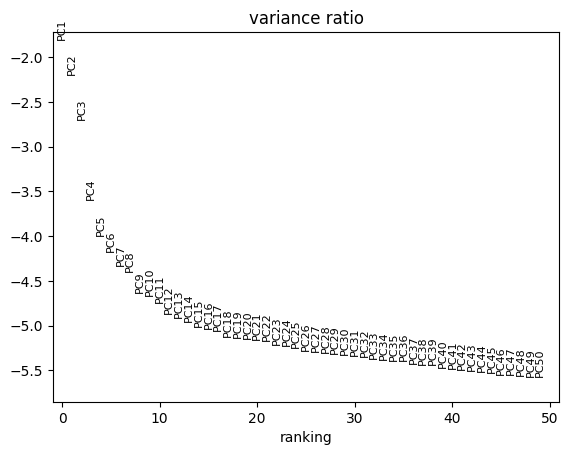

In [20]:
plt.rcdefaults()
sc.tl.pca(adata_all)
sc.pl.pca_variance_ratio(adata_all, n_pcs=50, log=True)
sc.pp.neighbors(adata_all, n_neighbors=30, n_pcs=40, metric="cosine")

In [21]:
adata_all

AnnData object with n_obs × n_vars = 556862 × 266
    obs: 'cell', 'centroid_x', 'centroid_y', 'centroid_z', 'component', 'volume', 'surface_area', 'scale', 'region', 'sample_id', 'proseg_cluster', 'output_folder', 'n_genes', 'n_counts'
    uns: 'log1p', 'pca', 'neighbors'
    obsm: 'spatial', 'X_pca'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

### UMAP

In [ ]:
sc.tl.umap(
    adata_all,
    min_dist=0.05,
    spread=1.5,
    negative_sample_rate=20,
)

In [ ]:
sc.pl.umap(adata_all, color = ['sample_id'])

### CLUSTERING

In [ ]:
resolutions = [0.5, 1,1.5, 2,2.5,3,3.5]

for resolution in resolutions:
    key = f'leiden_{resolution}'

    if key in adata_all.obs.columns:
        print(f"Skipping {resolution}: {key} already exists.")
    else:
        print(f"Clustering at resolution {resolution}...")
        sc.tl.leiden(adata_all, resolution=resolution, key_added=key)
        print("Done.")

    # plot UMAP
    sc.pl.umap(adata_all, color=key, legend_loc='on data', frameon=False)

In [ ]:
adata_all.obs['output_folder_2'] = adata_all.obs.output_folder.str.split('__', expand = True)[4]

In [ ]:
adata_all.obs['sample_id'] = adata_all.obs['output_folder_2'] + '-' + adata_all.obs['Num'].astype(str)

### VISUALIZATION

In [ ]:
# usage
plot_spatial_compact_fast(
    adata_all,
    color="leiden_1",
    groupby="sample_id",
    spot_size=3,
    cols=3,
    height=10,
    legend_col_width=1.0,
    background="white",

)

In [ ]:
adata_all.write(base_dir + 'ED_proseg_clustered_filtered.h5ad')

In [ ]:
adata_all.X.max()

In [ ]:
adata_all

### DGE

In [ ]:
adata_raw = sc.read_h5ad(base_dir+'ED_5k_filtered_raw.h5ad')

In [ ]:
adata_raw

In [ ]:
adata_all.layers['counts'] = adata_raw.X.copy()

In [ ]:
adata_all.X = adata_all.layers['counts'].copy()

In [ ]:
sc.pp.normalize_total(adata_all)
sc.pp.log1p(adata_all)

In [ ]:
## --- Find marker genes per cluster ---
sc.tl.rank_genes_groups(adata_all, groupby="leiden_1", method="t-test")
sc.pl.rank_genes_groups(adata_all, n_genes=25, sharey=False)

# get a tidy table of top markers
markers = sc.get.rank_genes_groups_df(adata_all, group=None)
markers.head()

In [ ]:
marker_genes = pd.DataFrame({
    group: adata_all.uns['rank_genes_groups']['names'][group][:20]
    for group in adata_all.uns['rank_genes_groups']['names'].dtype.names
})


In [ ]:
for col in marker_genes.columns: 
    print(col)
    genes = marker_genes[col].tolist()
    print(" ".join(genes))
    print(' ')

### VISUALIZATION OF EACH CLUSTER

In [ ]:
sc.pl.umap(adata_all, color='leiden_1', legend_loc='on data', frameon=False, )

In [ ]:
for cluster in sorted(adata_all.obs['leiden_1'].unique().astype(int)):
    cl_str = str(cluster)
    print(cl_str)
    print(marker_genes[cl_str].tolist())

    plot_spatial_compact_fast(
        adata_all,
        color="leiden_1",          # match the thing you're looping over
        groupby="sample_id",
        spot_size=3,
        cols=4,
        height=10,
        legend_col_width=1.0,
        background="black",
        highlight=[cl_str],           # highlight just this cluster
    )

In [173]:
# Extract top 5 marker genes per group into dict
marker_dict = {
    group: list(adata_all.uns["rank_genes_groups"]["names"][group][:3])
    for group in adata_all.uns["rank_genes_groups"]["names"].dtype.names
}

marker_dict

{'0': ['MYH11', 'ACTA2', 'MYLK'],
 '1': ['ACTA2', 'MYH11', 'CSRP1'],
 '2': ['ACTA2', 'MYH11', 'CSRP1'],
 '3': ['CCL14', 'NDRG1', 'NR4A1'],
 '4': ['MYH11', 'SOST', 'ACTA2'],
 '5': ['ACTA2', 'MYH11', 'SMTN'],
 '6': ['ACTA2', 'MYLK', 'MYH11'],
 '7': ['ACTA2', 'MYH11', 'MYLK'],
 '8': ['ACTA2', 'CSRP1', 'MYH11'],
 '9': ['CCL14', 'PECAM1', 'SHANK3'],
 '10': ['COL1A1', 'COL3A1', 'COMP'],
 '11': ['CD74', 'C1QC', 'CD14'],
 '12': ['COL1A1', 'COL3A1', 'COMP'],
 '13': ['TNXB', 'LRP1', 'LTBP2'],
 '14': ['COL1A1', 'COL3A1', 'COMP'],
 '15': ['MYH11', 'ACTA2', 'CSRP1'],
 '16': ['MYH11', 'ACTA2', 'MYLK'],
 '17': ['CCL14', 'PLAT', 'SHANK3'],
 '18': ['ACTA2', 'MYH11', 'MYLK'],
 '19': ['SHANK3', 'EGFL7', 'ITGB4'],
 '20': ['COL3A1', 'COL1A1', 'CCDC80'],
 '21': ['TNXB', 'MRC2', 'LRP1'],
 '22': ['CCL14', 'EPAS1', 'NR4A1'],
 '23': ['NOTCH3', 'MYH9', 'ACTA2'],
 '24': ['ACTA2', 'MYH11', 'SMTN'],
 '25': ['ACTA2', 'MYH11', 'CSRP1'],
 '26': ['LRP1', 'CFH', 'CXCL12'],
 '27': ['ACTA2', 'MYH11', 'MCAM'],
 '28': ['ACT

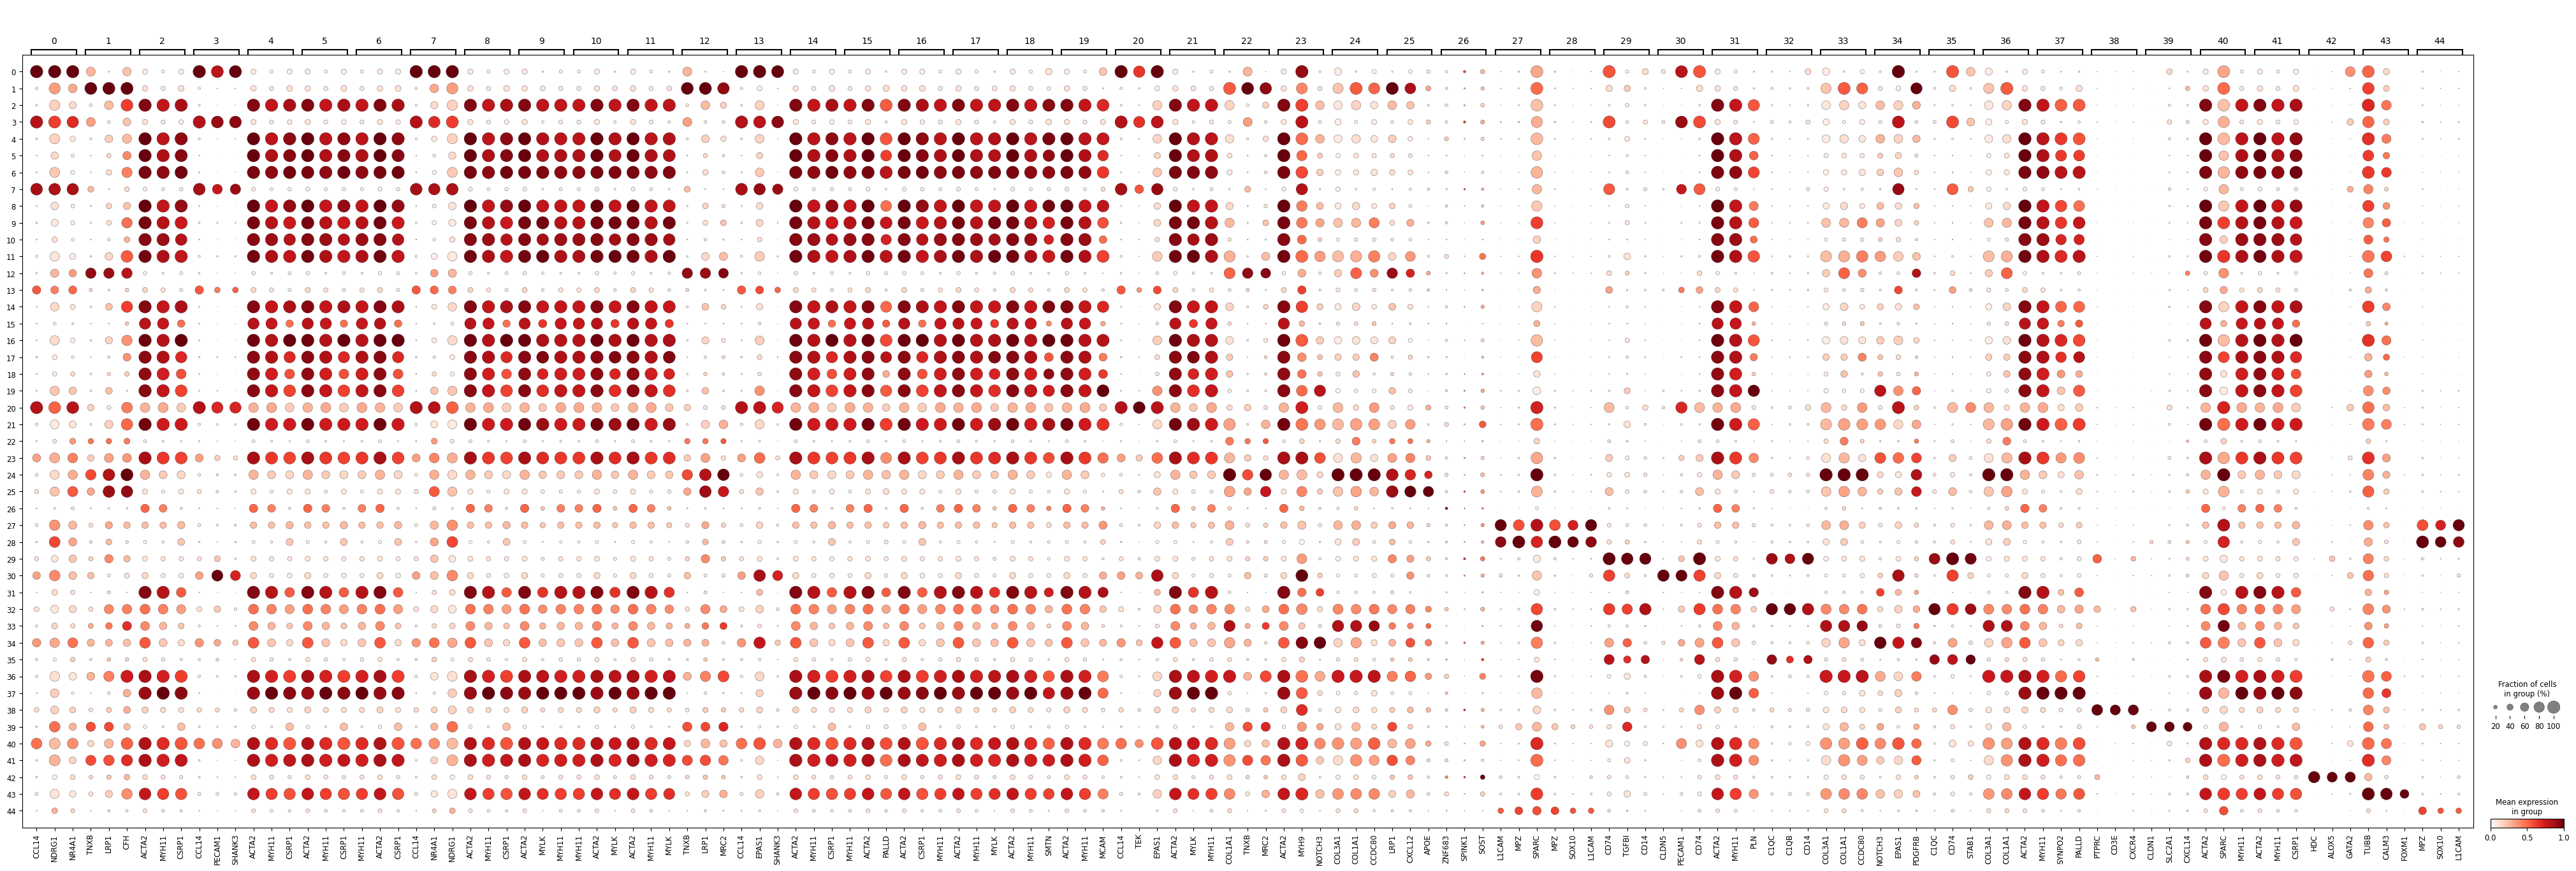

In [45]:
sc.pl.dotplot(adata_all, marker_dict, 
              groupby="leiden_3.5", 
              standard_scale="var",
             )


In [39]:
adata_all.write('../../../data/EAE_proseg_clustered_all_sections.h5ad')

In [ ]:
adata_all

In [40]:
annotation_clusters = pd.read_csv('/Users/christoffer/Downloads/annotation_proseg_clusters_107_sections.csv', sep = ';')

In [41]:
annotation_clusters

,Cluster,Level1,Level2,Level3,Level3.1
0,0,Neuron,Neuron,Canonical neuron,General excitatory/inhibitory neurons
1,1,Immune,Lymphoid,T cells,T cells (mixed CD4/CD8)
2,2,Glia,Oligodendrocyte,GM-oligodendrocyte,Mature oligodendrocyte
3,3,Neuron,Neuron (Inhibitory),Dorsal horn inh neuron,GABAergic-leaning neurons
4,4,Glia,Oligodendrocyte,WM-oligodendrocyte,Myelinating oligodendrocyte
...,...,...,...,...,...
61,61,Vascular,Endothelial,Arterial/venous endothelial cells,Arterial/venous endothelial cells
62,62,Glia,Oligodendrocyte,GM-oligodendrocyte,Mature oligodendrocytes
63,63,Neuron,PNS-like neuron,Neuon,Sncg+ sensory-like neurons
64,64,Glia,Oligodendrocyte,WM-oligodendrocyte,Myelinating oligodendrocytes


In [42]:
for column in annotation_clusters.columns: 
    dict_ = dict(zip(annotation_clusters.Cluster, annotation_clusters[column]))
    adata_all.obs[column] = adata_all.obs['louvain_3.5'].astype(int).map(dict_).astype(str)

In [43]:
adata_all.obs

,cell,centroid_x,centroid_y,centroid_z,component,volume,surface_area,scale,region,sample_id,...,louvain_1.5,louvain_2,louvain_2.5,louvain_3,louvain_3.5,Cluster,Level1,Level2,Level3,Level3.1
original_cell_id,,,,,,,,,,,,,,,,,,,,,
oclmdeen-1,0,7110.611328,1507.569336,0.382246,1,17.25,118.0,1.0,cell_boundaries,G3_L1_0,...,13,41,39,38,41,41,Stromal,Perineurial-like,Perineurial/stromal cells/DRG,Perineurial/stromal cells
jcdmnbco-1,1,7313.494141,1239.939209,0.252358,3,13.25,122.0,1.0,cell_boundaries,G3_L1_0,...,3,1,1,42,48,48,Unknown,Unknown,Unknown,Unknown
jcdphnka-1,3,7325.328125,1252.360840,0.471591,5,11.00,104.0,1.0,cell_boundaries,G3_L1_0,...,21,20,27,29,10,10,Neuron,Neuron,Synaptic signaling neurons,Synaptic signaling neurons
ocminppo-1,4,7319.113770,1253.966553,0.366379,3,7.25,98.0,1.0,cell_boundaries,G3_L1_0,...,3,1,1,42,48,48,Unknown,Unknown,Unknown,Unknown
ocmbegbh-1,7,7163.492188,1492.625977,0.420455,1,8.25,104.0,1.0,cell_boundaries,G3_L1_0,...,3,1,1,15,11,11,Immune,Myeloid,DA-microglia,Inflammatory antigen-presenting microglia
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
odddbhpa-1,7959,8764.948242,3035.172119,0.165698,1,10.75,96.0,1.0,cell_boundaries,S3-T3_2,...,3,1,1,15,11,11,Immune,Myeloid,DA-microglia,Inflammatory antigen-presenting microglia
ifleglib-1,7960,8850.878906,2884.109863,0.640306,1,36.75,256.0,1.0,cell_boundaries,S3-T3_2,...,18,19,13,45,52,52,Stromal,Fibroblast,Fibroblast,Perivascular fibroblast-like
igccgini-1,7961,8851.315430,2921.180664,0.333791,5,45.50,286.0,1.0,cell_boundaries,S3-T3_2,...,13,10,13,28,25,25,Glia,PNS glia,Schwann glia,Schwann cell–like glia


In [44]:
adata_all.write('../../../data/EAE_proseg_clustered_annotated_107_sections.h5ad')

In [ ]:
for column in annotation_clusters.columns: 
    sc.pl.umap(adata_all, color=column, legend_loc='on data', frameon=False, legend_fontsize="x-small")

In [47]:
adata_all.write('../../../data/EAE_proseg_clustered_all_sections_annotated.h5ad')